# 🏦 Exploratory Data Analysis of Public Transit Operations: 
### Insights for MetroMove Transit Solutions

*Analyzing trip performance, passenger behavior, and fare patterns to support operational decision-making*

---

## Problem Statement
*MetroMove has extensive trip data but lacks actionable insights due to messy and incomplete records, limiting their understanding of trip performance, passenger behaviour, and fare patterns constraining improvement in operations*


## Specific Objectives
- *Clean and preprocess the dataset to ensure data quality*
- *Perform Exploratory Data Analysis (EDA)*
- *Implore descriptive statistics to summarize key metrics*
- *Perform univariate, bivariate, and multivariate analyses to uncover insights*
- *Create visualizations that effectively communicate findings*
- *Clear documentations of analysis and actionable recommendations*


## Workflow Overview
```
Raw Data →  EDA (Initial Exploration)→ Cleaning and Preprocessing → Visualizations → Statistical Analysis → Actionable Recommendations
```

---
### STEP 1: Install Missingno

In [1]:
!pip install missingno

---
### STEP 2: Import Libraries

In [2]:
# Data Cleaning, Manipualtion and Visualization
import pandas as pd

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

#Display DataFrames and visual objects
from IPython.display import display

---
### STEP 3: Load Dataset

In [3]:
df = pd.read_excel("Transport_Trips.xlsx")

---
### STEP 4: EDA - Initial Data Exploration

In [4]:
# Inspect Dataset (top 5)

df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [5]:
# Inspect Dataset (bottom 5)

df.tail()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
995,TRIP0996,train,North Station,West End,2024-01-01 22:35:00,NaN,40.546670,51.0,2024-02-11,Saturday,NaN,NaN
996,TRIP0997,Bus,Central,West End,2024-01-01 22:36:00,63.0,7.772635,35.0,2024-02-11,Thursday,NaN,NaN
997,TRIP0998,FERRY,West End,North Station,2024-01-01 22:37:00,23.0,NaN,8.0,2024-02-11,Saturday,NaN,NaN
998,TRIP0999,Tram,South Point,Central,2024-01-01 22:38:00,9.0,43.300617,169.0,2024-02-11,Sunday,NaN,NaN
999,TRIP1000,train,Airport,West End,2024-01-01 22:39:00,34.0,8.168803,21.0,2024-02-11,Tuesday,NaN,NaN


---
###### The dataset shows some inconsistencies in text formatting in the 'mode of transport' and 'arrival station' columns
###### There are missing values in key columns including 'passenger count', 'fare amount' and 'trip duration', and some irregularities in station naming
###### Columns 10 and 11 are unnamed with missing values
---

In [6]:
# Checking Dimensionality

print(f' rows: {df.shape[0]:,} | columns: {df.shape[1]:,}')

 rows: 1,000 | columns: 12


In [7]:
# Features (Column) Examination

df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

In [8]:
# Defining Features (Column)

numerical_columns = ['Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes','Unnamed: 10']

categorical_columns = ['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station', 'Day_of_Week', 'Unnamed: 11']

print(f'num_col: ({len(numerical_columns)}): {numerical_columns}')

print(f'cat_col: ({len(categorical_columns)}): {categorical_columns}')

num_col: (4): ['Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes', 'Unnamed: 10']
cat_col: (6): ['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station', 'Day_of_Week', 'Unnamed: 11']


In [9]:
# Investigating for Anomalies

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        900 non-null    float64       
 6   Fare_Amount            900 non-null    float64       
 7   Trip_Duration_Minutes  900 non-null    float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Unnamed: 10            0 non-null      float64       
 11  Unnamed: 11            299 non-null    object        
dtypes: datetime64[ns](2), float64(4), object(6)
memory usage: 93.9+

In [10]:
# Descriptive Statistics (Categorical)

df.describe(include = 'object')

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Day_of_Week,Unnamed: 11
count,1000,1000,1000,1000,1000,299
unique,1000,9,7,7,7,2
top,TRIP1000,Bus,North Station,South Point,Sunday,F
freq,1,147,171,171,167,250


In [11]:
# Descriptive Statistics (Numerical Columns)

df.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Unnamed: 10
count,1000,900.000000,900.000000,900.000000,1000,0.0
mean,2024-01-01 14:19:30,49.154444,25.360742,94.270000,2024-01-21 08:03:50.400000,NaN
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,NaN
25%,2024-01-01 10:09:45,25.000000,12.818196,49.750000,2024-01-11 00:00:00,NaN
50%,2024-01-01 14:19:30,48.000000,25.403856,97.500000,2024-01-21 00:00:00,NaN
75%,2024-01-01 18:29:15,72.000000,37.866623,138.000000,2024-02-01 00:00:00,NaN
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,NaN
std,NaN,27.698270,14.464556,50.634982,NaN,NaN


In [12]:
# Investigating for Duplicates
   # Investigating for fully duplicated entries

duplicates = df[df.duplicated(keep=False)]

if duplicates.empty:
    print('No duplicate record found')
else:
    display(duplicates)

No duplicate record found


In [13]:
   # Further Investigation for Hidden Key-based Duplicates (if multiple trips shared the same trip ID)

df[df.duplicated(subset=['Trip_ID'], keep = False)]

if duplicates.empty:
    print('No duplicate record found')
else:
    display(duplicates)

No duplicate record found


In [14]:
   # Investigating for multiple records of same trips (counting repeated trips based on specific columns)
df.duplicated(subset=[
    'Trip_ID',
    'Mode_of_Transport',
    'Departure_Station',
    'Arrival_Station',
    'Departure_Time',
    'Trip_Date'
]).sum()

if duplicates.empty:
    print('No duplicate record found')
    print()
    print('No repeated trips with identical details or multiple trips sharing the same Trip ID')
else:
    display(duplicates)
    

No duplicate record found

No repeated trips with identical details or multiple trips sharing the same Trip ID


In [15]:
# Investigating Data for Inconsistencies and whitespace errors

for col in df.columns:
    if col not in ['Trip_ID', 'Departure_Time', 'Passenger_Count', 'Fare_Amount', 'Trip_Duration_Minutes', 'Trip_Date']:
        print("\n", col)
        print(df[col].unique())


 Mode_of_Transport
['FERRY' 'Tram' 'bus' 'Ferry' 'fErry' 'Train' 'train' 'BUS' 'Bus']

 Departure_Station
['West End' 'North Station' 'Central' 'Downtown' 'South Point' ' Central '
 'Airport']

 Arrival_Station
['airport' 'Downtown' 'North Station' 'Central' 'South Point' 'West End'
 'Airport']

 Day_of_Week
['Sunday' 'Saturday' 'Tuesday' 'Monday' 'Thursday' 'Wednesday' 'Friday']

 Unnamed: 10
[nan]

 Unnamed: 11
['F' 'T' nan]


---
###### Whitespace noted in the 'departure station' column
---

In [16]:
# Handling Inconsistencies

df["Mode_of_Transport"] = df["Mode_of_Transport"].str.strip().str.title()

df["Departure_Station"] = df["Departure_Station"].str.strip().str.title()

df["Arrival_Station"] = df["Arrival_Station"].str.strip().str.title()
print()
print('Inconsistencies in text format and whitespace errors successfully handled')


Inconsistencies in text format and whitespace errors successfully handled


In [17]:
df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F


In [18]:
# Handling Missing Data
   # Investigating the data for missing values

df.isnull().sum()


Trip_ID                     0
Mode_of_Transport           0
Departure_Station           0
Arrival_Station             0
Departure_Time              0
Passenger_Count           100
Fare_Amount               100
Trip_Duration_Minutes     100
Trip_Date                   0
Day_of_Week                 0
Unnamed: 10              1000
Unnamed: 11               701
dtype: int64

In [19]:
   # Percentage Missing Data Per Column

df.isnull().sum() / len(df) * 100

Trip_ID                    0.0
Mode_of_Transport          0.0
Departure_Station          0.0
Arrival_Station            0.0
Departure_Time             0.0
Passenger_Count           10.0
Fare_Amount               10.0
Trip_Duration_Minutes     10.0
Trip_Date                  0.0
Day_of_Week                0.0
Unnamed: 10              100.0
Unnamed: 11               70.1
dtype: float64

###### 10% Missing values found in these columns: passenger count, fare amount and trip duration
###### 100% Missing Values noticed in unnamed column 10
###### 70% Missing values noted in unnamed column 11

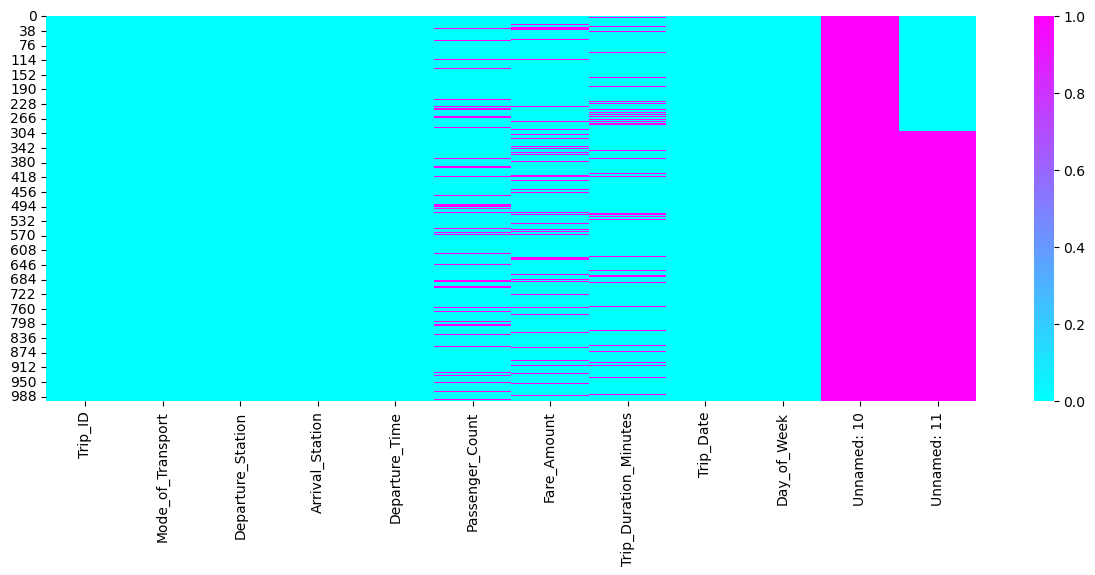

In [20]:
   # Investigating the data for missing values by visualization

plt.figure(figsize = (15, 5))
sns.heatmap(df.isnull(), cbar = True, cmap = 'cool');

---
###### Heatmap uncovered scattered but recurring pattern of missing values in passenger count, fare amount, and trip duration across records
###### Unnamed column 10 completely missing throughout the dataset
###### Unnamed column 11 almost entirely missing throughout the dataset
---

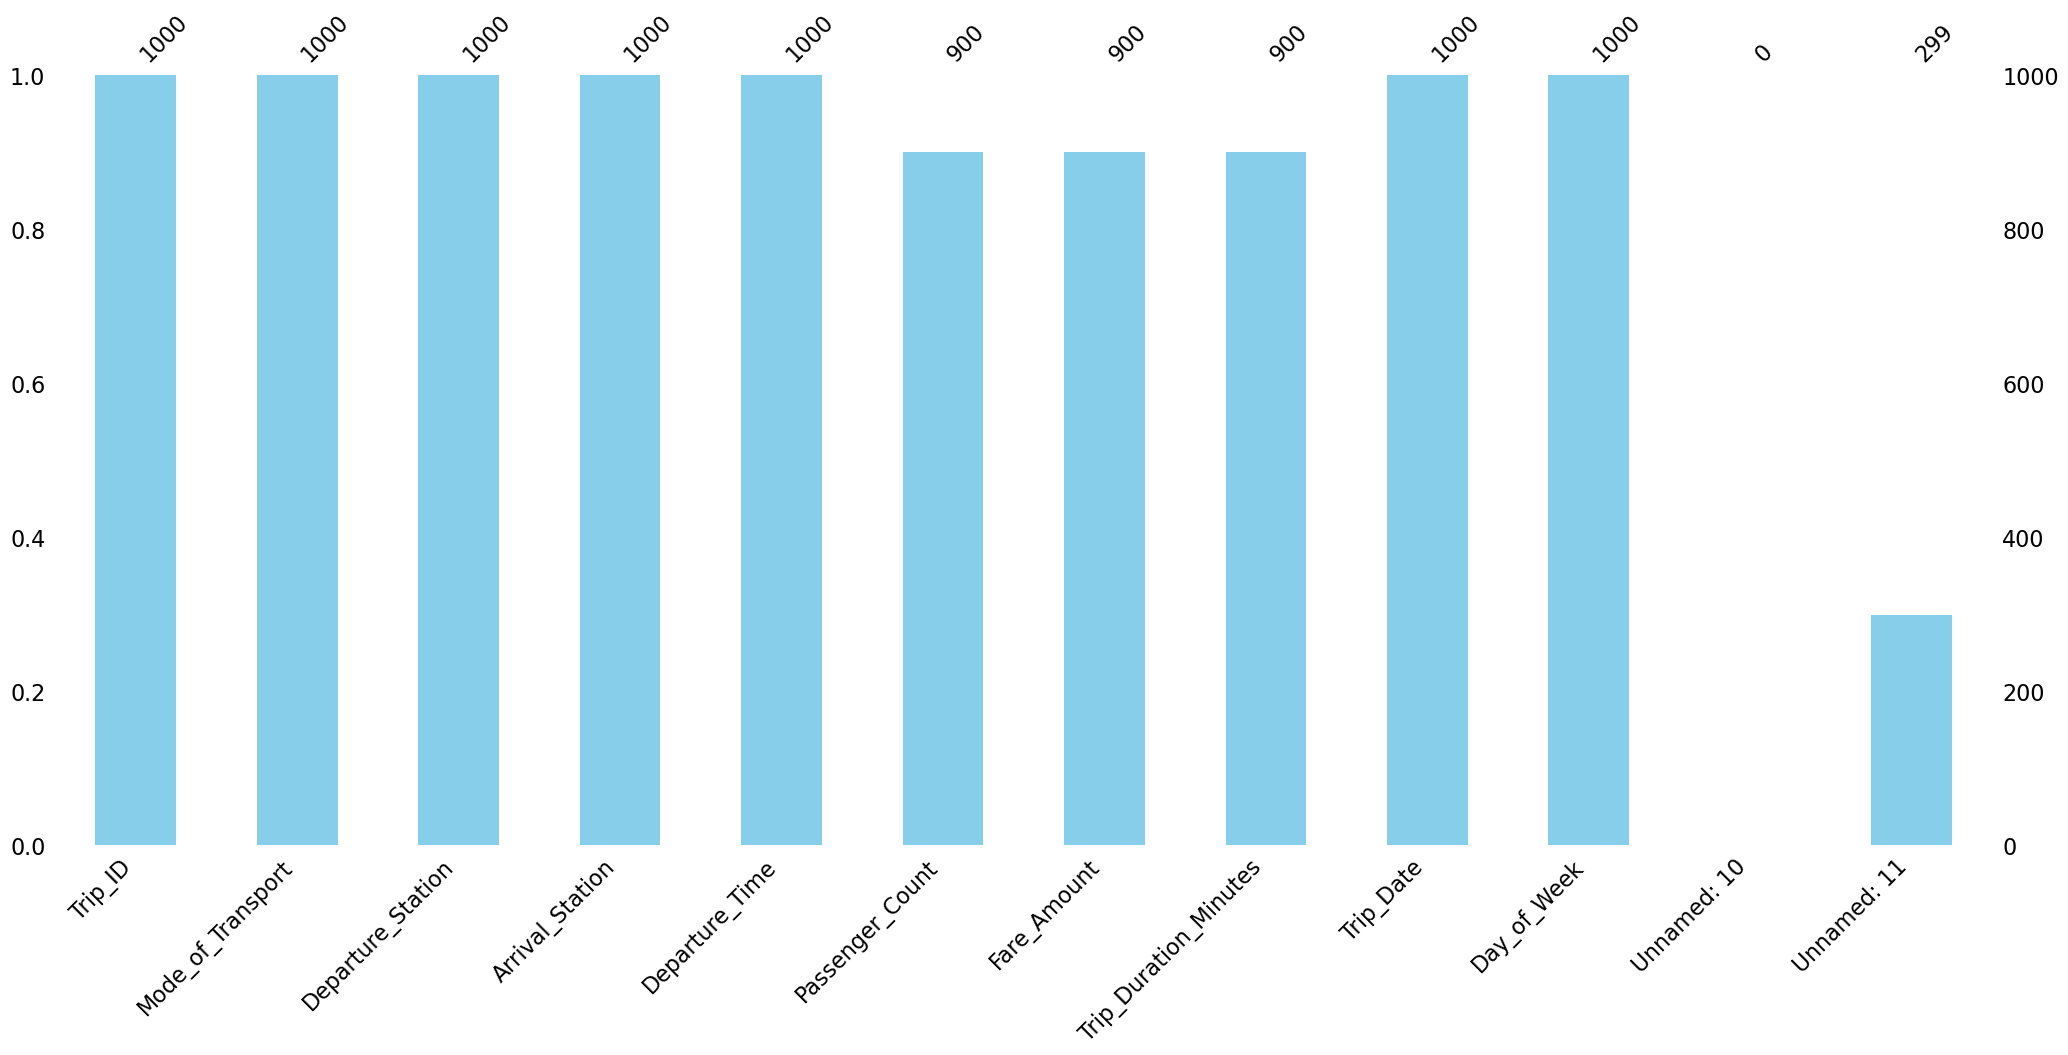

In [21]:
 # Investigating for missing values in data (method: by missing data visualization)
msno.bar(df, color = 'skyblue');

---
###### *Confirms missingness as previously documented*
---

In [22]:
   # Dropping Unnamed columns 10 and 11

df = df.drop(columns = ['Unnamed: 10','Unnamed: 11'])

In [23]:
df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday


---
###### *Both columns 10 and 11 were unnamed and had 100% and 70% missing values respectively. They offered no analytic value, hence they were dropped.*
---

In [24]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 1. Passenger_Count:
     #a. Is missingness dependent on Mode_of_Transport or random

df.groupby('Mode_of_Transport')['Passenger_Count'].apply(lambda x: x.isna().mean() * 100)

Mode_of_Transport
Bus       8.433735
Ferry     8.710801
Train    13.580247
Tram     10.144928
Name: Passenger_Count, dtype: float64

---
###### *Passenger count missingness varies by mode of transport, indicating a patterned (MAR) mechanism*
###### *This is supported by higher missingness in Train (~13.6%) relative to other modes*
---

In [25]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 1. Passenger_Count:
    #b. Is missingness clustered in certain stations or random?

df.groupby('Departure_Station')['Passenger_Count'].apply(lambda x: x.isna().mean() * 100)

Departure_Station
Airport           8.917197
Central          10.096154
Downtown          8.982036
North Station    11.695906
South Point       8.695652
West End         11.320755
Name: Passenger_Count, dtype: float64

---
###### *Passenger count missingness by departure station shows mild variation (≈9%–12%), suggesting a weak station-driven dependency*
###### *It does not provide strong evidence of a structured missingness type*
---

In [26]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 1. Passenger_Count:
   #c. Does missingness happen at certain times of day?

df.groupby('Departure_Time')['Passenger_Count'].apply(lambda x: x.isna().mean() * 100)

Departure_Time
2024-01-01 06:00:00      0.0
2024-01-01 06:01:00      0.0
2024-01-01 06:02:00      0.0
2024-01-01 06:03:00      0.0
2024-01-01 06:04:00      0.0
                       ...  
2024-01-01 22:35:00    100.0
2024-01-01 22:36:00      0.0
2024-01-01 22:37:00      0.0
2024-01-01 22:38:00      0.0
2024-01-01 22:39:00      0.0
Name: Passenger_Count, Length: 1000, dtype: float64

---
###### *Passenger count missingness shows a strong time-dependent pattern, with certain timestamps exhibiting complete data loss*
###### *This indicates a Missing At Random (MAR) mechanism likely driven by system or operational factors*
---

In [27]:
# Filling Passenger_Count missing values with Group-based median imputation

df['Hour'] = pd.to_datetime(df['Departure_Time']).dt.hour

df['Passenger_Count'] = df.groupby(
    ['Mode_of_Transport', 'Hour']
)['Passenger_Count'].transform(lambda x: x.fillna(x.median()))

print('Missing values in passengers count column successfully filled')

Missing values in passengers count column successfully filled


In [28]:
df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,6


---
###### *Passenger count missingness is not random but dependent on mode of transport and time of day, with weak influence from departure station*
###### *Therefore, a mode-of-transport and time-based grouped median imputation was used to preserve operational patterns while maintaining stability in the dataset*
---

In [29]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 2. Fare Amount:
   #a. Does missingness in fare amount happen in certain mode of transport

df.groupby(['Mode_of_Transport'])['Fare_Amount'] \
  .apply(lambda x: x.isna().mean() * 100)

Mode_of_Transport
Bus       9.939759
Ferry     8.710801
Train    12.345679
Tram      8.695652
Name: Fare_Amount, dtype: float64

---
###### *Fare amount missingness shows slight variation across mode of transport, but not strong enough to suggest a highly structured dependency*
---

In [30]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 2: Fare Amount:
   #b. Is missingness in Fare amount clustered in certain departure station?


df.groupby(['Departure_Station'])['Fare_Amount'] \
  .apply(lambda x: x.isna().mean() * 100)

Departure_Station
Airport           8.280255
Central           9.134615
Downtown          7.784431
North Station    11.695906
South Point       9.420290
West End         13.836478
Name: Fare_Amount, dtype: float64

---
###### *Fare amount missingness shows moderate variation across departure stations, with West End and North station exhibiting higher missing rates, suggesting a station-dependent Missing At Random (MAR) pattern*
---

In [31]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns

   # 2: Fare Amount:
   #c. Does missingness in fare amount happen on certain departure time?

df.groupby(['Departure_Time'])['Fare_Amount'] \
  .apply(lambda x: x.isna().mean() * 100)

Departure_Time
2024-01-01 06:00:00      0.0
2024-01-01 06:01:00      0.0
2024-01-01 06:02:00    100.0
2024-01-01 06:03:00      0.0
2024-01-01 06:04:00    100.0
                       ...  
2024-01-01 22:35:00      0.0
2024-01-01 22:36:00      0.0
2024-01-01 22:37:00    100.0
2024-01-01 22:38:00      0.0
2024-01-01 22:39:00      0.0
Name: Fare_Amount, Length: 1000, dtype: float64

---
###### *Fare amount missingness exhibits strong time-dependent patterns, with certain timestamps showing complete data loss, indicating system-driven missingness*
---

In [32]:
# filling fare amount missing values with Group-based median imputation

df['Fare_Amount'] = df.groupby(
    ['Mode_of_Transport', 'Departure_Station', 'Arrival_Station']
)['Fare_Amount'].transform(lambda x: x.fillna(x.median()))

In [33]:
df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,27.389927,NaN,2024-01-01,Tuesday,6


---
###### *Fare amount missingness is not random and is primarily driven by time-based system patterns, with moderate variation across departure stations, supporting MAR mechanism*
###### *Station- and time-based grouped median values wasn used to fill missingness*
---

In [34]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns
  
   # 3: Trip Duration:
   #a. Does missingness in fare amount happen on certain days of the week?

df.groupby(['Day_of_Week'])['Trip_Duration_Minutes'] \
  .apply(lambda x: x.isna().mean() * 100)

Day_of_Week
Friday       10.563380
Monday       13.380282
Saturday     10.958904
Sunday       10.179641
Thursday      8.474576
Tuesday       8.163265
Wednesday     7.971014
Name: Trip_Duration_Minutes, dtype: float64

---
###### *Trip duration missingness varies across days of the week, with higher rates observed on Mondays, indicating a patterned (MAR) mechanism*
---

In [35]:
# Investigating if missingness is random or patterned in the passenger count, fare amount and trip duration columns
  
   # 3: Trip Duration:
   #b. Is missingness in Trip duration dependent on the mode of transport?

df.groupby(['Mode_of_Transport'])['Trip_Duration_Minutes'] \
  .apply(lambda x: x.isna().mean() * 100)

Mode_of_Transport
Bus       9.939759
Ferry     9.059233
Train     9.876543
Tram     12.318841
Name: Trip_Duration_Minutes, dtype: float64

---
###### *Trip duration missingness shows only slight variation across transport modes*
---

In [36]:
#Filling trip duration missing values with Group-based median imputation

df['Trip_Duration_Minutes'] = df.groupby(
    ['Mode_of_Transport', 'Day_of_Week']
)['Trip_Duration_Minutes'].transform(lambda x: x.fillna(x.median()))

In [37]:
df.head(3)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6
2,TRIP0003,Bus,Central,North Station,2024-01-01 06:02:00,91.0,27.389927,100.0,2024-01-01,Tuesday,6


---
###### *Trip duration missingness varies across both day of week and mode of transport, indicating a missing-at-random mechanism*
###### *Missing values were imputed using a grouped median over both variables*
---

---

### STEP 6: Data Validation
---

In [38]:
# Re-Investigating for missing data (after filling)

df.isnull().sum()

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
Hour                     0
dtype: int64

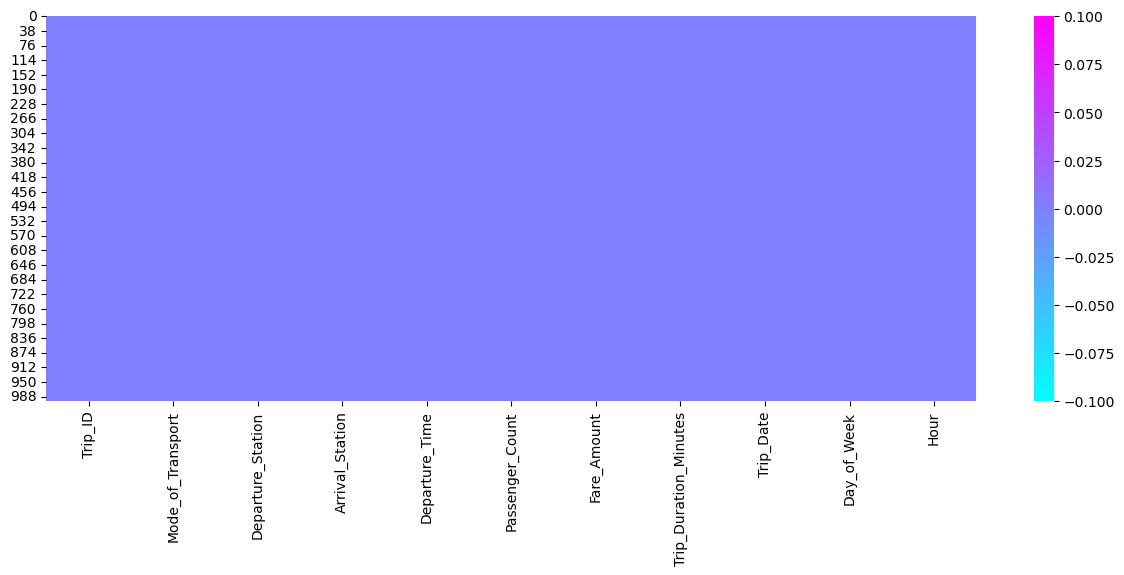

In [39]:
# Re-Investigating for missing data (by visualization), after filling 
plt.figure(figsize = (15,5))
sns.heatmap(df.isnull(), cbar=True, cmap = 'cool');

In [40]:
df.info()

print()
print('Missing data successfully handled')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   datetime64[ns]
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Hour                   1000 non-null   int32         
dtypes: datetime64[ns](2), float64(3), int32(1), object(5)
memory usage: 82.2+ KB

Missing data successfully handled


---
### STEP 7: Visualization of Relevant variables
---

##### Q1. What is the overall distribution of Passengers?

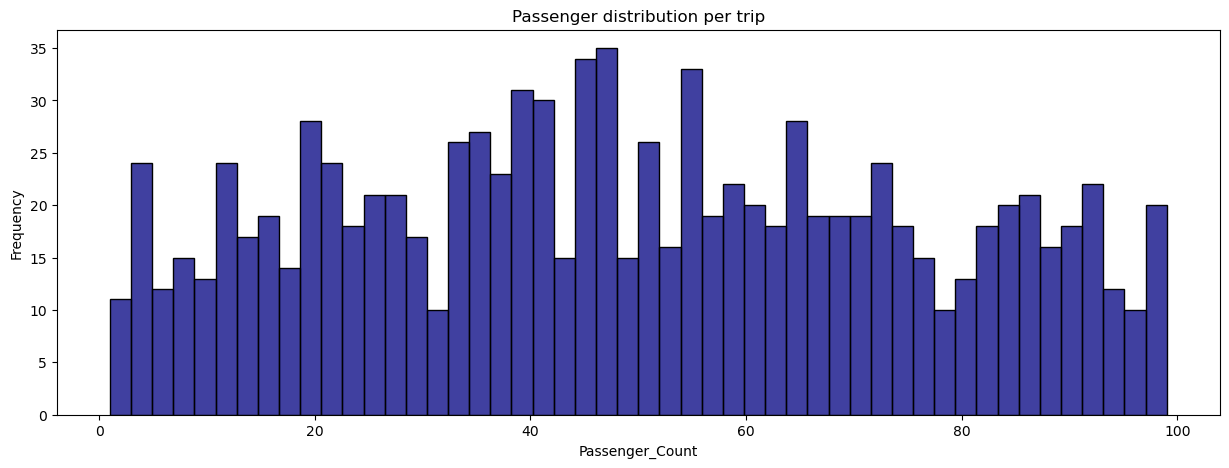

In [41]:
plt.figure(figsize = (15,5))
sns.histplot(df['Passenger_Count'], bins = 50, color = 'navy');
plt.title('Passenger distribution per trip')
plt.ylabel('Frequency')
plt.show()

---
###### **Insights**: Passenger counts are fairly distributed across a wide range, with most trips carrying a moderate to high number of passengers
---

In [42]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Hour'],
      dtype='object')

##### Q2. What is the Total Trips by Days of the Week?

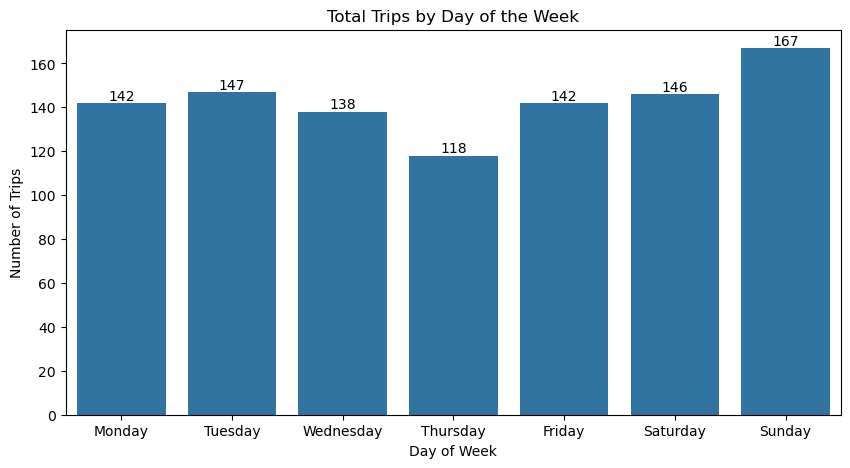

In [43]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10,5))
ax = sns.countplot(x='Day_of_Week', data=df, order=order)

ax.bar_label(ax.containers[0])

plt.title('Total Trips by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')

plt.show()

---
###### **Insight**: Demand is lowest on Thursday but peaks sharply on Sunday, indicating a strong weekend usage pattern likely driven by leisure travel
---

##### Q3. How many trips does each transport mode contribute?

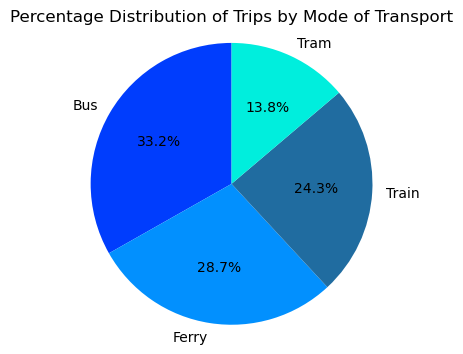

In [44]:
plt.figure(figsize=(4, 4))
mode_counts = df['Mode_of_Transport'].value_counts()
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', startangle=90, colors = ['#003DFD', '#0290FE', '#206CA0', '#00EEDD'])
plt.title('Percentage Distribution of Trips by Mode of Transport')
plt.axis('equal')

plt.show()

---
###### **Insight**: Bus is the most preferred mode of transport, with trams significantly underutilized compared to other options
---

##### Q4. Which departure stations generate the most trips?

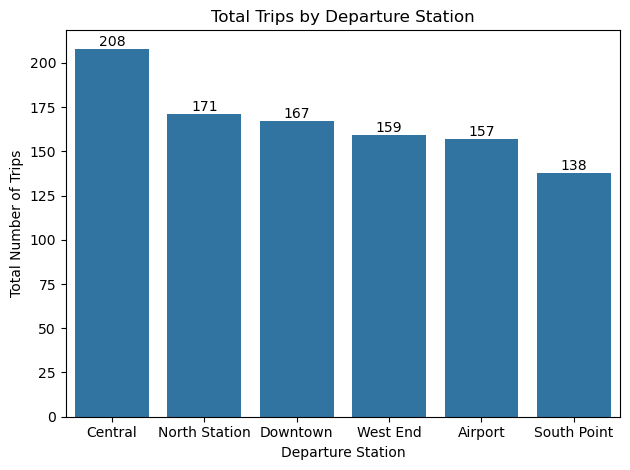

In [45]:
ax = sns.countplot(x = df['Departure_Station'], order = df['Departure_Station'].value_counts(ascending = False).index)
values =  df['Departure_Station'].value_counts(ascending = False).values
ax.bar_label(container = ax.containers[0], labels = values);

plt.title('Total Trips by Departure Station')
plt.xlabel('Departure Station')
plt.ylabel('Total Number of Trips')
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

---
###### **Insight**: Trips are concentrated at Central station and then steadily decline across the other stations, with South Point having the fewest departures
---

##### Q5. Which stations generate the most revenue per passenger?

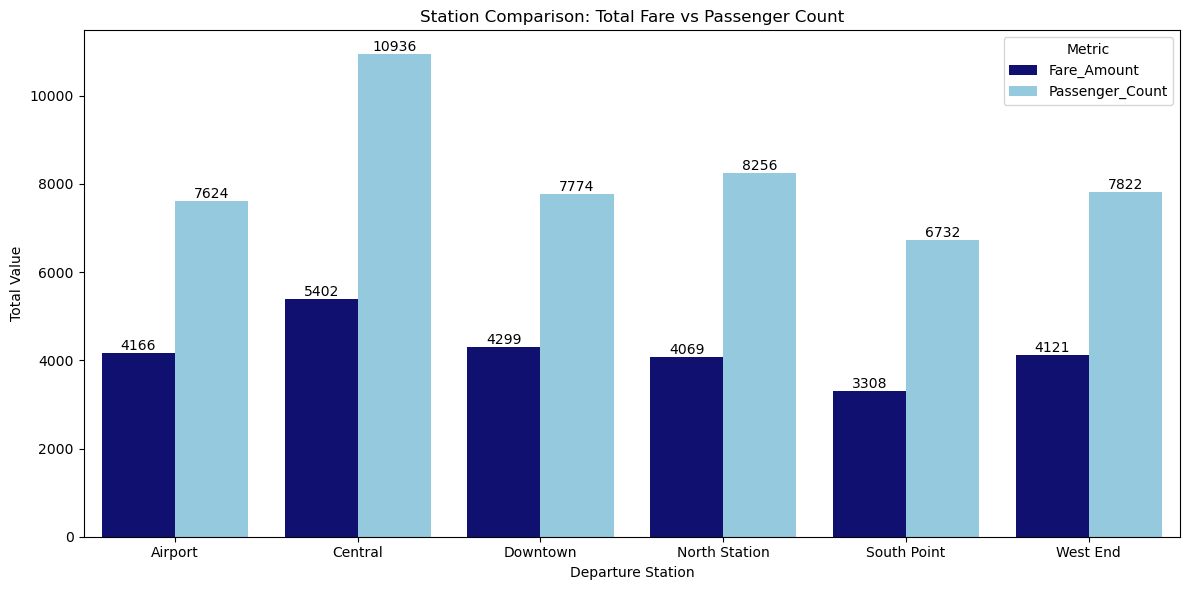

In [46]:
station_metrics = df.groupby('Departure_Station').agg({'Fare_Amount': 'sum', 'Passenger_Count': 'sum'}).reset_index()

station_long = station_metrics.melt(id_vars='Departure_Station', value_vars=['Fare_Amount', 'Passenger_Count'], var_name='Metric', value_name='Value')

plt.figure(figsize=(12,6))
ax = sns.barplot(data=station_long, x='Departure_Station', y='Value', palette= ['navy', 'skyblue'], hue='Metric')

for container in ax.containers: ax.bar_label(container, fmt='%.0f')

plt.title('Station Comparison: Total Fare vs Passenger Count')
plt.xlabel('Departure Station')
plt.ylabel('Total Value')
plt.xticks(rotation=360)
plt.tight_layout()

plt.show()

###### **Insight**: Central station handles the highest passenger volume and generates the most fare revenue, while South Point has the lowest activity across both metrics

##### Q6. What is the average number of passengers per trip by transport mode?

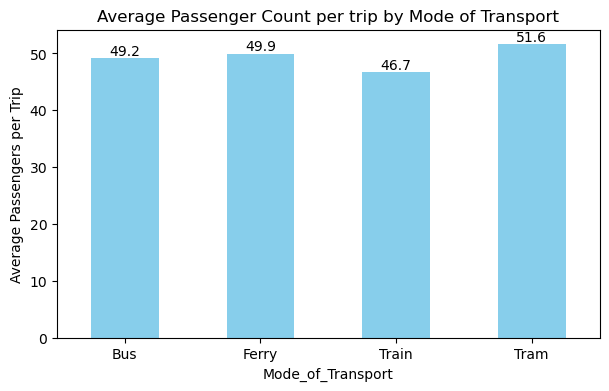

In [47]:
avg_passengers = df.groupby('Mode_of_Transport')['Passenger_Count'].mean()
plt.figure(figsize=(7,4))
ax = avg_passengers.plot(kind='bar', color = 'skyblue')

# add values on top of bars
for i, v in enumerate(avg_passengers):
    ax.text(i, v, f"{v:.1f}", ha='center', va='bottom')

plt.ylabel('Average Passengers per Trip')
plt.xticks(rotation=360)
plt.title('Average Passenger Count per trip by Mode of Transport')
plt.show()

---
###### **Insight**: In comparison to typical transport capacity standards, buses align reasonably with expected usage, whereas trams, trains, and ferries show clear underutilization, highlighting opportunities to optimize service planning and demand alignment in the other modes of transport
---

##### Q7. How does Trip Duration Vary by Route and Mode of Transport

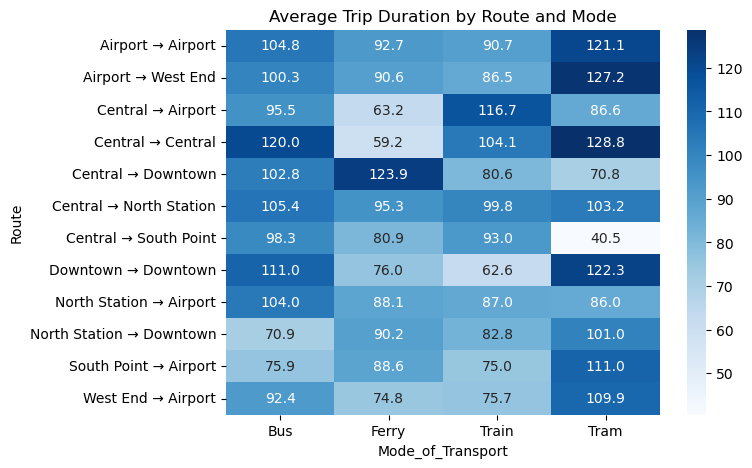

In [48]:
 #Creating route feature
df['Route'] = df['Departure_Station'] + " → " + df['Arrival_Station']
route_counts = df['Route'].value_counts()
valid_routes = route_counts[route_counts > 30].index
df_filtered = df[df['Route'].isin(valid_routes)]

#Creating Pivot
pivot = df_filtered.pivot_table(
    index='Route',
    columns='Mode_of_Transport',
    values='Trip_Duration_Minutes',
    aggfunc='mean'
)
#Creating Visualization
plt.figure(figsize=(7,5))
sns.heatmap(pivot, cmap='Blues', annot=True, fmt=".1f")
plt.title("Average Trip Duration by Route and Mode")
plt.show()

##### **Insight**: Compared to expected performance, where trains should generally be fastest, there were inconsistencies such that on several routes, slower modes like buses or ferries match or outperform trains—indicating potential inefficiencies in train operations or route design
##### E.g. Central → Airport by train (116 mins) is slower than bus (95 mins) and even tram (86 mins) 
##### Central → Central by train (104 mins) is slower than ferry (59 mins)

##### Q8. What is the transport demand by the time of the day for each mode of transport?

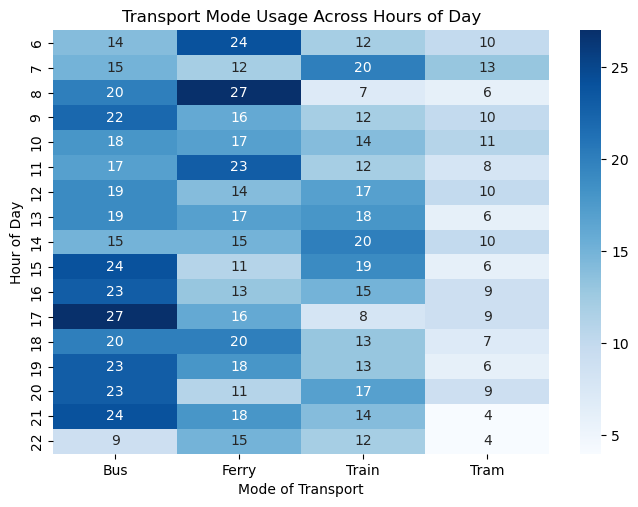

In [64]:
 # Creating a table for Transport Mode Vs Clock Hour
mode_time = pd.crosstab(df['Hour'], df['Mode_of_Transport'])

 # Visualization
plt.figure(figsize=(8, 5.5))
sns.heatmap(mode_time, cmap='Blues', annot=True, fmt='d')
plt.title('Transport Mode Usage Across Hours of Day')
plt.xlabel('Mode of Transport')
plt.ylabel('Hour of Day')

plt.show()

###### **Insights:**
###### Peak demand is concentrated on buses in the afternoon/evening and ferries in the early morning, while trams are underutilized across all hours
###### Demand peaks are clearly time- and mode-specific
###### Buses peak in the late afternoon and evening (5 - 9 PM), ferries peak in the morning (8 AM), trains peak around early morning and early afternoon (7 AM and 2 PM), while trams utilization consistently declines with a modest peak at 7 AM

##### Q9. How does fare amount change with trip duration?

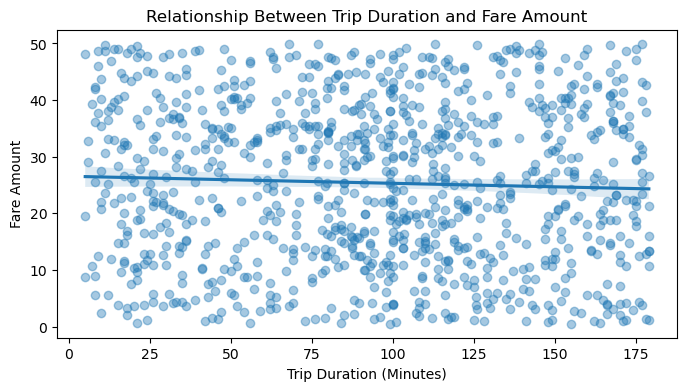

In [66]:
plt.figure(figsize=(8,4))
sns.regplot(data=df, x='Trip_Duration_Minutes', y='Fare_Amount', scatter_kws={'alpha':0.4})
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Fare Amount')
plt.title('Relationship Between Trip Duration and Fare Amount')

plt.show()

###### **Insights:**
###### No clear relationship exist between the trip duration and the amount of transport fare paid

##### Q10. How does the average trip duration vary by different departure times of the day?

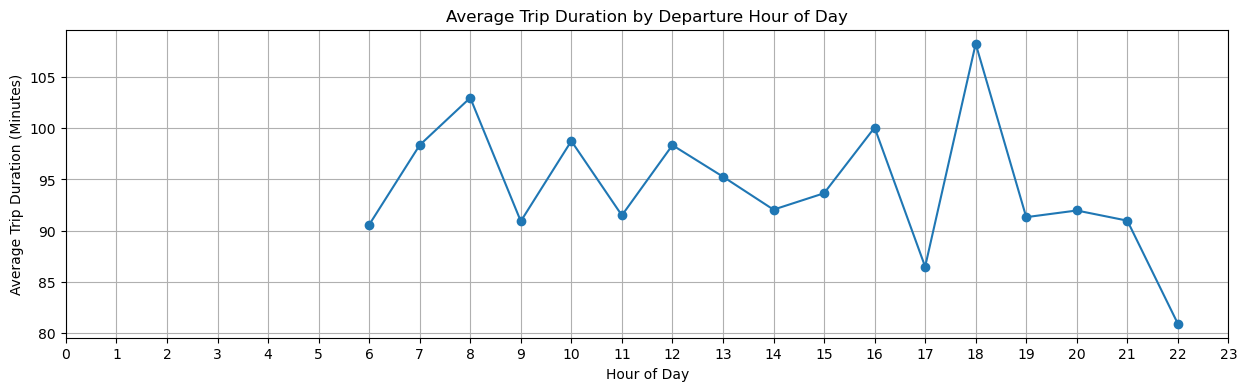

In [67]:
  # Extract hour (0–23) from departure time to analyze time-of-day patterns
df['Hour'] = df['Departure_Time'].dt.hour

  # Calculate the average trip duration for each hour
hourly_duration = df.groupby('Hour')['Trip_Duration_Minutes'].mean()

# Create Visualization
plt.figure(figsize=(15,4))
hourly_duration.plot(kind='line', marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trip Duration (Minutes)')
plt.title('Average Trip Duration by Departure Hour of Day')
plt.xticks(range(0,24))
plt.grid()

plt.show()

###### Insights:
###### 1. Average trip duration peaks at 8 AM and 6 PM, aligning with typical morning and evening commute hours, while the shortest trips occur late at night (from 10PM)
###### 2. Average trip duration peaks at 8 AM and 6 PM, aligning with typical morning and evening commute hours, while the shortest trips occur late at night (10 PM onwards), suggesting longer, busier routes dominate peak hours and quicker, lighter trips characterize off-peak travel

In [68]:
df.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour,Route
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6,West End → Airport
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6,North Station → Downtown


##### Q11. What time of day do most passengers travel?

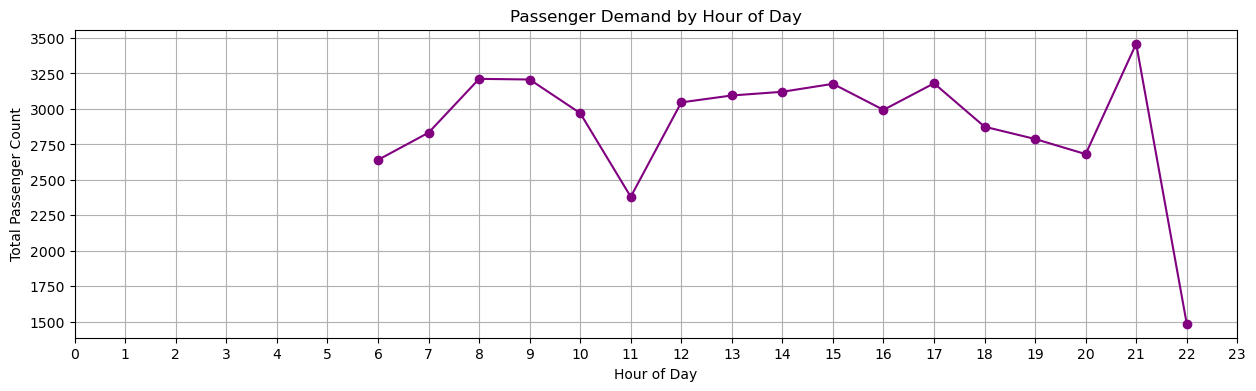

In [69]:
hourly_passengers = df.groupby('Hour')['Passenger_Count'].sum()

plt.figure(figsize=(15,4))
hourly_passengers.plot(kind='line', marker='o', color = 'purple')  
plt.xlabel('Hour of Day')
plt.ylabel('Total Passenger Count')
plt.title('Passenger Demand by Hour of Day')

plt.xticks(range(0,24))
plt.grid()

plt.show()

##### Insight: Demand peaks at 8 AM and 9 PM, dips sharply at 11 AM, and drops off steeply after 10 PM, pointing to two distinct rush periods with quiet late-night travel

##### Q12. How does fare amount vary across different times of the day?

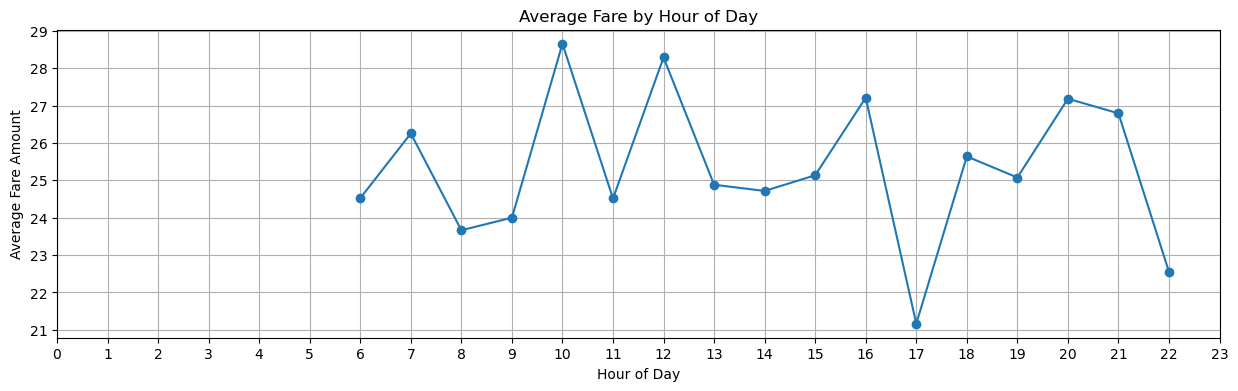

In [70]:
plt.figure(figsize=(15,4))
hourly_fare = df.groupby('Hour')['Fare_Amount'].mean()  
hourly_fare.plot(kind='line', marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount')
plt.title('Average Fare by Hour of Day')
plt.xticks(range(0,24))
plt.grid()

plt.show()

###### Insights
###### Passenger demand peaks at 8 AM and again at 9 PM, with a notable midday dip at 11 AM and the sharpest drop at 10 PM onwards, indicating two distinct demand surges (morning commute and late evening) separated by relatively stable midday activity

##### Q13. How does fare amount vary by day of the week?

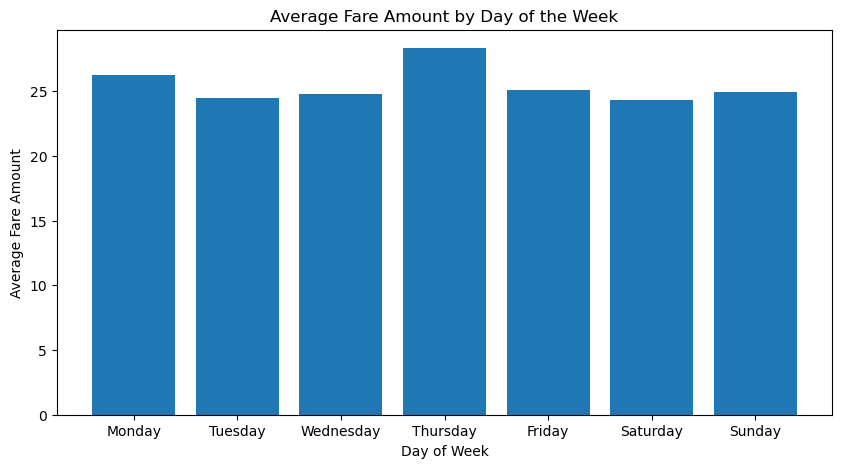

In [56]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10,5))
avg_fare_day = df.groupby('Day_of_Week')['Fare_Amount'].mean().reindex(order)
plt.bar(avg_fare_day.index, avg_fare_day.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Fare Amount')
plt.title('Average Fare Amount by Day of the Week')
plt.xticks(rotation=360)

plt.show()

---
###### **Insight**: Even though demand is lowest on Thursday, the highest revenue was generated on Thursday suggesting that fare patterns are being driven more by factors other than sheer demand
---

##### Q14. What is the average fare amount for each mode of transport?

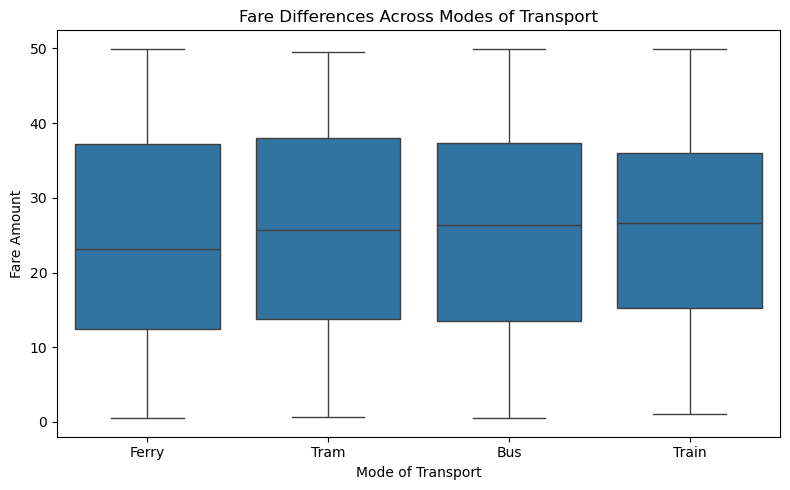

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Mode_of_Transport', y='Fare_Amount')

plt.title('Fare Differences Across Modes of Transport')
plt.xlabel('Mode of Transport')
plt.ylabel('Fare Amount')

plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

###### **Insight**: All four modes charge roughly the same fares, medians are close and ranges overlap heavily, meaning passengers pay similar amounts regardless of which mode they take

##### Q15. How does fare amount affect passenger usage?

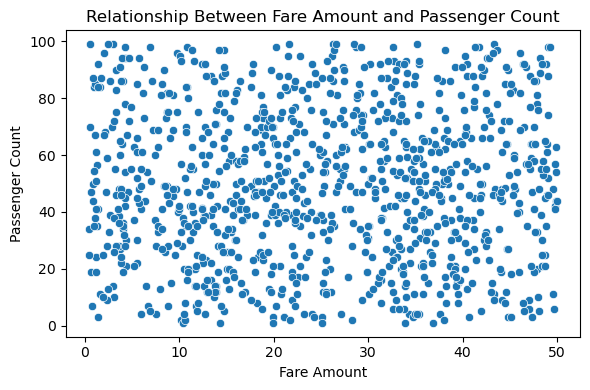

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Fare_Amount', y='Passenger_Count')

plt.title('Relationship Between Fare Amount and Passenger Count')
plt.xlabel('Fare Amount')
plt.ylabel('Passenger Count')
plt.tight_layout()
plt.show()

---
###### **Insight**: No relationship exist between the pasenger count and fare amount, indicating that passenger count is not driven by fare amount
---

In [59]:
df.head(2)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Hour,Route
0,TRIP0001,Ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,6,West End → Airport
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,6,North Station → Downtown


##### Q16. How do key operational metrics (trip demand, passenger volume, and revenue) change over time?

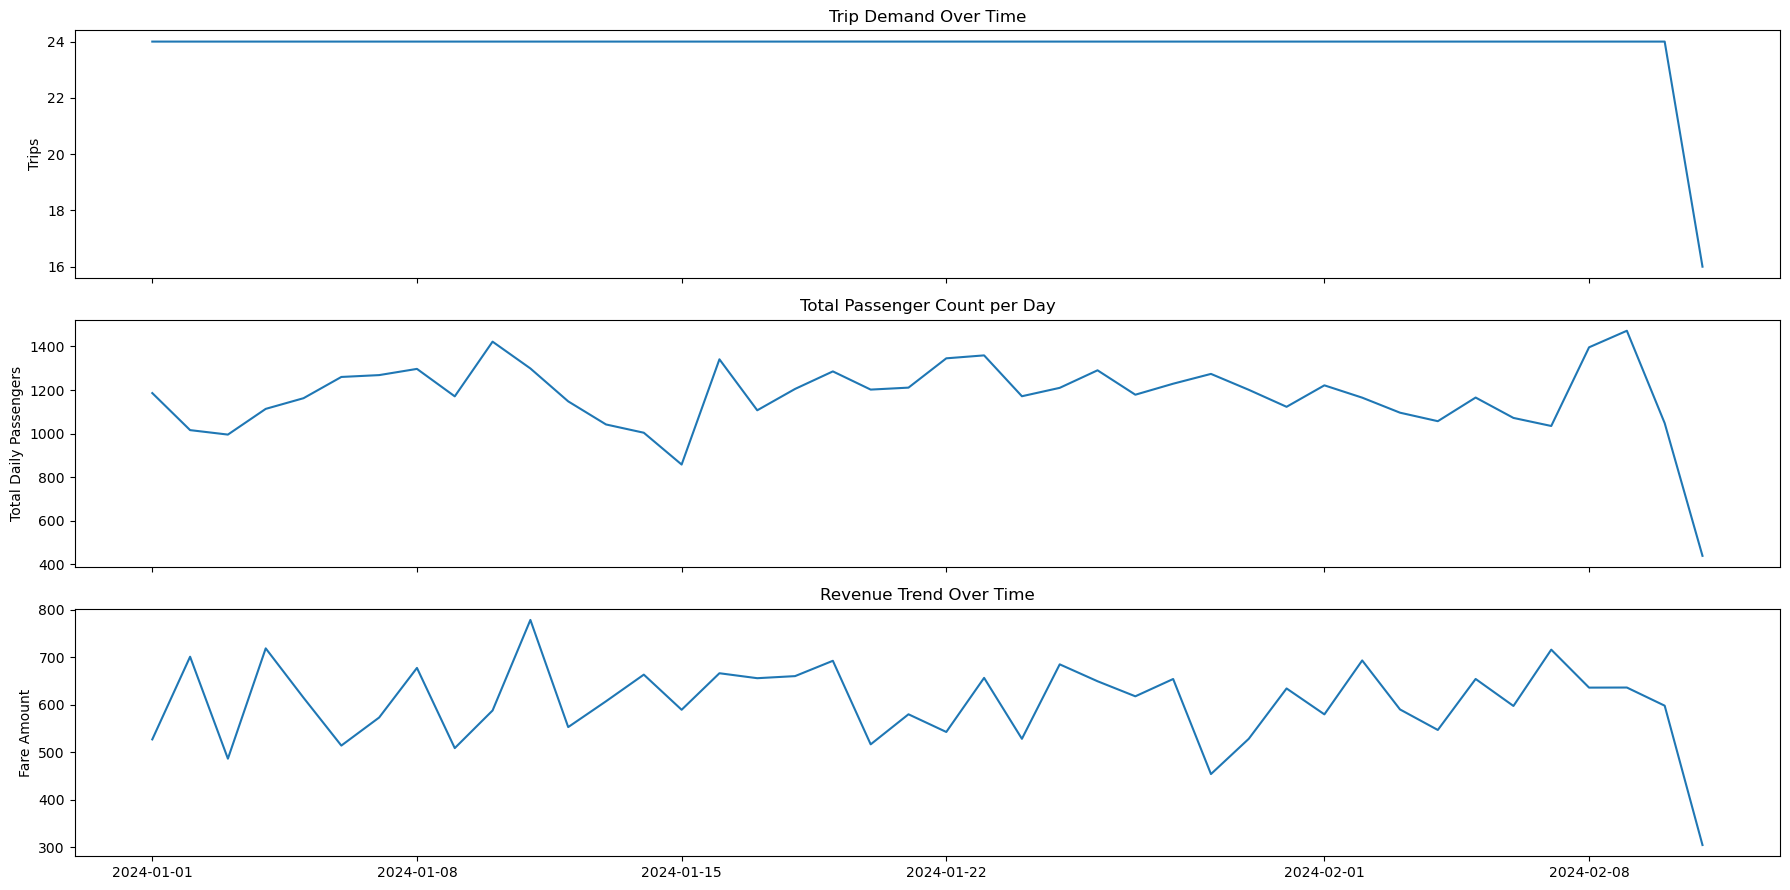

In [60]:
df['Trip_Date'] = pd.to_datetime(df['Trip_Date'])

# Aggregations
daily_trips = df.groupby('Trip_Date')['Trip_ID'].count()
daily_passengers = df.groupby('Trip_Date')['Passenger_Count'].sum()
daily_revenue = df.groupby('Trip_Date')['Fare_Amount'].sum()
mode_trend = df.groupby(['Trip_Date', 'Mode_of_Transport'])['Trip_ID'].count().unstack()

# Create 2x2 subplot
fig, axes = plt.subplots(nrows = 3 , ncols = 1, figsize=(18,9), sharex=True)

# (0) Trips
axes[0].plot(daily_trips.index, daily_trips.values)
axes[0].set_title('Trip Demand Over Time')
axes[0].set_ylabel('Trips')

# (1) Passengers
axes[1].plot(daily_passengers.index, daily_passengers.values)
axes[1].set_title('Total Passenger Count per Day')
axes[1].set_ylabel('Total Daily Passengers')

# (2) Revenue
axes[2].plot(daily_revenue.index, daily_revenue.values)
axes[2].set_title('Revenue Trend Over Time')
axes[2].set_ylabel('Fare Amount')

plt.tight_layout()
plt.show()

---
##### **Insight**: Trip demand remained largely unstable over time, while passenger volume and revenue fluctuate day-to-day with similar patterns
---

##### Q17. How does trip volume vary over time across different modes of transport

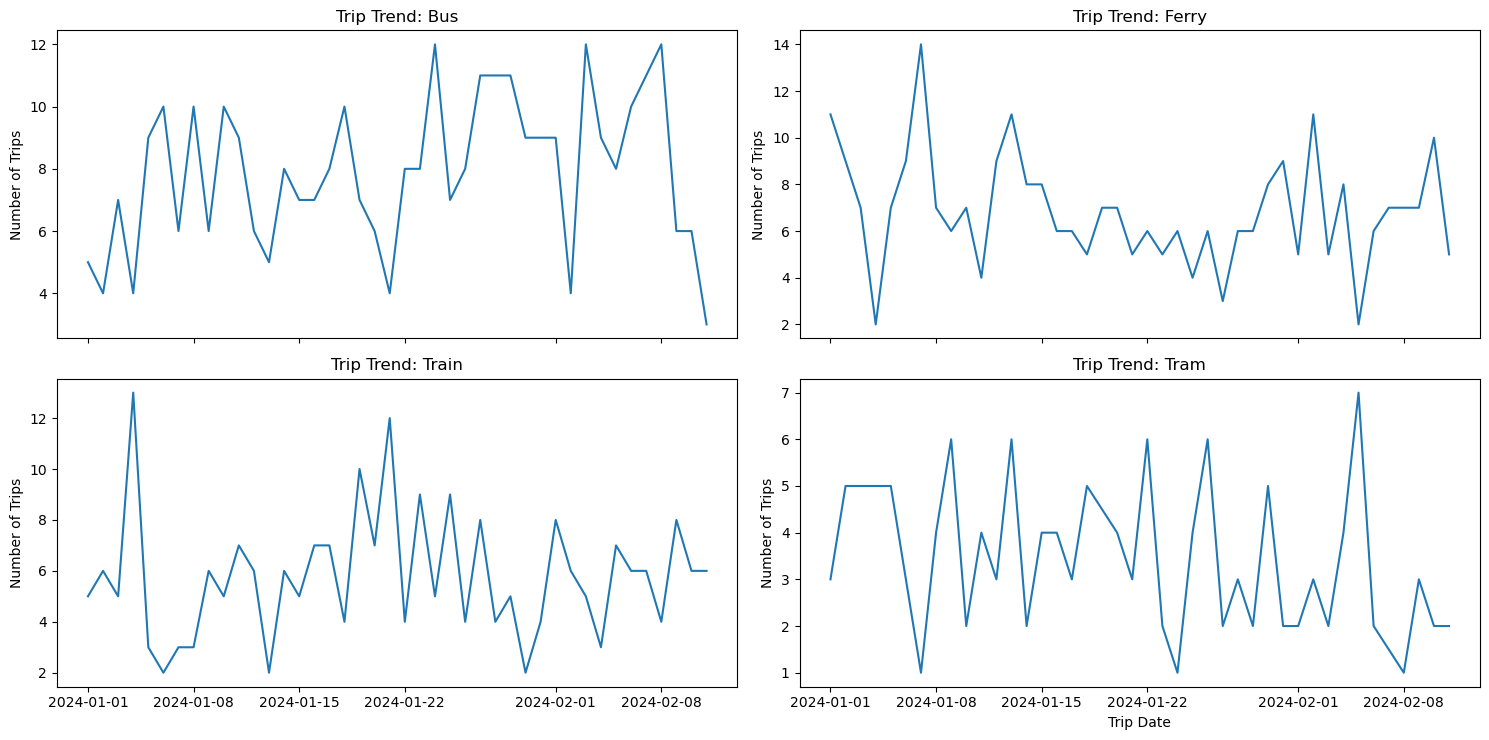

In [61]:
# Get top 4 modes
modes = df['Mode_of_Transport'].value_counts().index[:4]

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(15,7.5), sharex=True)
axes = axes.flatten()

for i, mode in enumerate(modes):
    mode_data = df[df['Mode_of_Transport'] == mode]
    
    trend = mode_data.groupby('Trip_Date')['Trip_ID'].count()
    
    axes[i].plot(trend.index, trend.values)
    axes[i].set_title(f'Trip Trend: {mode}')
    axes[i].set_ylabel('Number of Trips')

# Hide any empty subplot (if less than 4 modes)
for j in range(len(modes), 4):
    axes[j].axis('off')

plt.xlabel('Trip Date')
plt.xticks(rotation=360)
plt.tight_layout()
plt.show()

##### **Insights**: All mode of transport expressed volatility over time

---
### STEP 8: Descriptive Statistics (Post-Data Cleaning/Validation)


In [62]:
df.describe()

,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Hour
count,1000,1000.000000,1000.000000,1000.000000,1000,1000.000000
mean,2024-01-01 14:19:30,49.143500,25.364839,94.529000,2024-01-21 08:03:50.400000,13.840000
min,2024-01-01 06:00:00,1.000000,0.500576,5.000000,2024-01-01 00:00:00,6.000000
25%,2024-01-01 10:09:45,28.000000,13.625091,55.000000,2024-01-11 00:00:00,10.000000
50%,2024-01-01 14:19:30,48.000000,25.446220,98.000000,2024-01-21 00:00:00,14.000000
75%,2024-01-01 18:29:15,70.000000,37.025708,132.250000,2024-02-01 00:00:00,18.000000
max,2024-01-01 22:39:00,99.000000,49.945184,179.000000,2024-02-11 00:00:00,22.000000
std,NaN,26.535161,13.981472,48.203358,NaN,4.816388


---
### Actionable Recommendations

#### 1. Capacity & Scheduling
- *Increase bus capacity during late afternoon and evening (5–9 PM) to meet its peak demand*
- *Optimize ferry scheduling around the 8 AM morning peak*
- *Deploy more trains around 7 AM and 2 PM when demand spikes*
- *Trim tram scheduling and use targeted incentives to address consistent underutilization across all hours*
- *Use historical trip data to anticipate demand shifts and adjust service levels accordingly*

#### 2. Route Optimization
- *Investigate train operations on underperforming routes*
- *Deploy trains only on routes where they hold a genuine speed advantage*
- *Introduce express train services on routes where trains are currently slower than buses and trams to restore their expected speed advantage*

### 3. Pricing & Demand
- *Align fares with demand especially on  Thursdays with the lowest demand and highest revenue*
- *Implement targeted interventions at South Point e.g. discounted fares or loyalty rewards to stimulate usage*